# This requires the field GEM_smoothed_2000dbar_for_SWOT.nc - will be available on Zenodo at https://zenodo.org/uploads/18889113 under the file name GEM_smoothed_2000dbar_for_SWOT.nc

In [1]:
import os
import glob
import numpy as np
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import gsw

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/xarray/backends/scipy_.py:39: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.io import netcdf_file as netcdf_file_base


In [2]:
def crop_swot_dataset(ds, lat_bounds=(-70, -60), lon_bounds=(-180, 180)):
    # Convert 0–360 → -180–180
    ds = ds.assign_coords(longitude=xr.where(ds.longitude <= 180, ds.longitude, ds.longitude - 360))

    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds

    mask = (
        (ds.latitude >= lat_min) & (ds.latitude <= lat_max) &
        (ds.longitude >= lon_min) & (ds.longitude <= lon_max)
    )
    ds_cropped = ds.where(mask, drop=True)

    if ds_cropped.sizes.get("num_lines", 0) == 0:
        return None
    return ds_cropped

In [6]:
GEM_all_smooth = xr.open_dataset('GEM_smoothed_2000dbar_for_SWOT.nc.nc')

In [7]:
swot_folder = "swot_data_full_cycle" #If you want to do this over multiple folders I;m sure its probably possible?
swot_files = sorted(glob.glob(os.path.join(swot_folder, "*.nc")))
lat_bounds = (-65, -45)


satGEM_list = []

for swot_file in tqdm(swot_files, desc="Processing SWOT passes"):
    try:
        swot_swath = xr.open_dataset(swot_file)
        swot_swath_cropped = crop_swot_dataset(swot_swath, lat_bounds=lat_bounds)

        swot_ssh = swot_swath_cropped.mdt + swot_swath_cropped.ssha_filtered

        if swot_ssh.isnull().all():
            print(f"Skipping empty SSH field: {os.path.basename(swot_file)}")
            continue

        # clip SWOT ssh to common static GEM ssh range
        swot_ssh_clip = swot_ssh.clip(min=GEM_all_smooth.ssh.min(), max=GEM_all_smooth.ssh.max())

        # interpolate smoothed static GEM onto SWOT longitude + ssh
        satGEM_swot = GEM_all_smooth.interp(
            longitude=swot_swath_cropped.longitude,
            ssh=swot_ssh_clip,
            method='linear'
        )

        # keep only valid SWOT ssh pixels
        satGEM_swot = satGEM_swot.where(np.isfinite(swot_ssh))

        # attach pass name
        satGEM_swot = satGEM_swot.expand_dims(
            pass_id=[os.path.basename(swot_file)]
        )

        satGEM_list.append(satGEM_swot)

    except Exception as e:
        print(f"Failed on {os.path.basename(swot_file)}: {e}")

if len(satGEM_list) > 0:
    satGEM_all = xr.concat(satGEM_list, dim="pass_id")
else:
    satGEM_all = None

Processing SWOT passes: 100%|██████████| 23/23 [01:34<00:00,  4.13s/it]
/jobfs/162476449.gadi-pbs/ipykernel_1746786/2177923132.py:43: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  satGEM_all = xr.concat(satGEM_list, dim="pass_id")


Failed on SWOT_L3_LR_SSH_Basic_474_026_20230329T191927_20230329T201032_v3.0.nc: [Errno -101] NetCDF: HDF error: '/g/data/jk72/jw2777/SWOT_case_study/swot_data_full_cycle/SWOT_L3_LR_SSH_Basic_474_026_20230329T191927_20230329T201032_v3.0.nc'


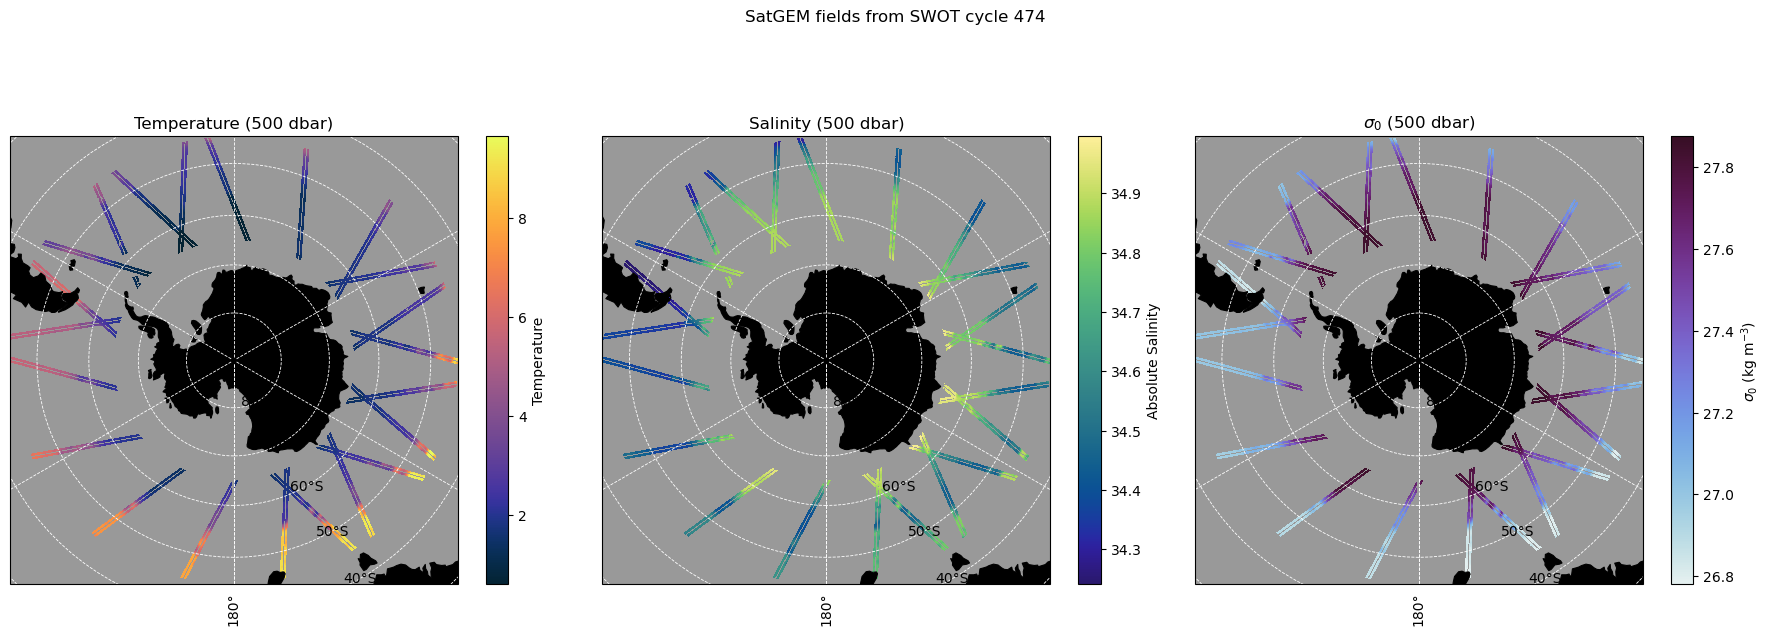

In [8]:
# ---------------------------
# choose pressure index
# ---------------------------
k = 50   # change as needed

# ---------------------------
# pull fields
# ---------------------------
CT = satGEM_all["temp"].isel(pressure=k)


SA = satGEM_all["sal"].isel(pressure=k)

# ---------------------------
# compute sigma0
# ---------------------------
sigma0 = xr.apply_ufunc(
    gsw.sigma0,
    SA,
    CT,
    dask="parallelized",
    vectorize=True,
    output_dtypes=[float],
)

sigma0.name = "sigma0"

# ---------------------------
# common color limits
# ---------------------------
temp_vmin = float(CT.min(skipna=True))
temp_vmax = float(CT.max(skipna=True))

salt_vmin = float(SA.min(skipna=True))
salt_vmax = float(SA.max(skipna=True))

sig_vmin = float(sigma0.min(skipna=True))
sig_vmax = float(sigma0.max(skipna=True))


def style_south_polar(ax):
    ax.set_facecolor("0.6")
    ax.set_extent([-180, 180, -80, -45], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="black")
    ax.coastlines(color="black", linewidth=0.8)

    gl = ax.gridlines(
        draw_labels=True,
        linestyle="--",
        color="white",
        linewidth=0.6
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"color": "black"}
    gl.ylabel_style = {"color": "black"}

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 7),
    subplot_kw={"projection": ccrs.SouthPolarStereo()}
)

# --- Temperature ---
ax = axes[0]
style_south_polar(ax)
pcm1 = None

for pid in satGEM_all.pass_id.values:
    ds_plot = satGEM_all.sel(pass_id=pid)
    pcm1 = ax.pcolormesh(
        ds_plot.longitude,
        ds_plot.latitude,
        ds_plot.temp.isel(pressure=k),
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmocean.cm.thermal,
        vmin=temp_vmin,
        vmax=temp_vmax
    )

cb1 = plt.colorbar(pcm1, ax=ax, shrink=0.7, pad=0.05)
cb1.set_label("Temperature")
ax.set_title(f"Temperature ({satGEM_all.pressure.isel(pressure=k).item():.0f} dbar)")

# --- Salinity ---
ax = axes[1]
style_south_polar(ax)
pcm2 = None

for pid in satGEM_all.pass_id.values:
    ds_plot = satGEM_all.sel(pass_id=pid)
    pcm2 = ax.pcolormesh(
        ds_plot.longitude,
        ds_plot.latitude,
        ds_plot["sal"].isel(pressure=k),
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmocean.cm.haline,
        vmin=salt_vmin,
        vmax=salt_vmax
    )

cb2 = plt.colorbar(pcm2, ax=ax, shrink=0.7, pad=0.05)
cb2.set_label("Absolute Salinity")
ax.set_title(f"Salinity ({satGEM_all.pressure.isel(pressure=k).item():.0f} dbar)")

# --- sigma0 ---
ax = axes[2]
style_south_polar(ax)
pcm3 = None

for pid in sigma0.pass_id.values:
    ds_plot = sigma0.sel(pass_id=pid)
    pcm3 = ax.pcolormesh(
        ds_plot.longitude,
        ds_plot.latitude,
        ds_plot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmocean.cm.dense,
        vmin=sig_vmin,
        vmax=sig_vmax
    )

cb3 = plt.colorbar(pcm3, ax=ax, shrink=0.7, pad=0.05)
cb3.set_label(r"$\sigma_0$ (kg m$^{-3}$)")
ax.set_title(rf"$\sigma_0$ ({satGEM_all.pressure.isel(pressure=k).item():.0f} dbar)")

plt.suptitle("SatGEM fields from SWOT cycle 474", y=0.98)
plt.tight_layout()
plt.show()